# Initialization

## Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

## Directories

In [2]:
data_dir = Path("data")
Path.mkdir(data_dir, exist_ok=True)

plot_dir = Path("plots")
Path.mkdir(plot_dir, exist_ok=True)

log_dir = Path("logs")
Path.mkdir(log_dir, exist_ok=True)

## Data reading

In [3]:
data_file = "Dataset_SL.xlsx"

### Define experimental data

In [4]:
# 1. Define the experimental data
experiment_data = pd.read_excel(data_dir / data_file, sheet_name="Datasheet")

In [5]:
# make the other columns as floats
experiment_data = experiment_data.astype(
    {
        "salt_concentration": float,
        "water_to_cement_ratio": float,
        "antisettling_concentration": float,
        "E_d": float,
        "KPI": float,
    }
)

# get optimization round for later use in saving
opt_round = experiment_data["opt_round"].iloc[-1]

In [6]:
experiment_data.dropna(subset=["E_d"], inplace=True)
experiment_data

,opt_round,salt,salt_concentration,water_to_cement_ratio,antisettling_concentration,kernel,acquisition,obj_func,n_rejected_before_accept,E_d,KPI,Notes
0,0,MgSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,39.392651,6.764730,NaN
1,0,CaCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,91.053468,2.427368,NaN
2,0,SrBr2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,159.169079,32.224874,NaN
3,0,MgCl2,0.50,1.00,0.00,NaN,NaN,NaN,NaN,88.671748,2.715363,NaN
4,0,CuSO4,0.50,1.00,0.00,NaN,NaN,NaN,NaN,9.658742,61.776688,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
97,4,MgCl2,0.15,1.25,0.00,RBF,EI,KPI,15.0,46.623793,4.038395,NaN
98,4,MgSO4,0.33,0.88,0.01,RBF,PI,KPI,34.0,23.165120,10.785614,NaN
99,4,MgCl2,0.55,1.07,1.07,RBF,LCB_low,KPI,8.0,57.119079,6.645415,NaN
100,4,Zn(NO3)2,0.16,1.24,1.04,RBF,LCB_med,KPI,4.0,41.951700,15.922248,NaN


# Plots

In [7]:
# Define fixed color maps
salt_colors = {
    "Al2(SO4)3": "#9e0142",
    "CaCl2": "#d53e4f",
    "CuSO4": "#f46d43",
    "K2CO3": "#fdae61",
    "KAl(SO4)2": "#fee08b",
    "LiCl": "#bfbfbf",
    "Mg(NO3)2": "#e6f598",
    "MgCl2": "#abdda4",
    "MgSO4": "#66c2a5",
    "SrBr2": "#3288bd",
    "Zn(NO3)2": "#5e4fa2",
}

# Remove datapoints with Notes
df_clean = experiment_data[experiment_data["Notes"] != "Penalizzato"]

## Objective function

## Optimization

### Sorted

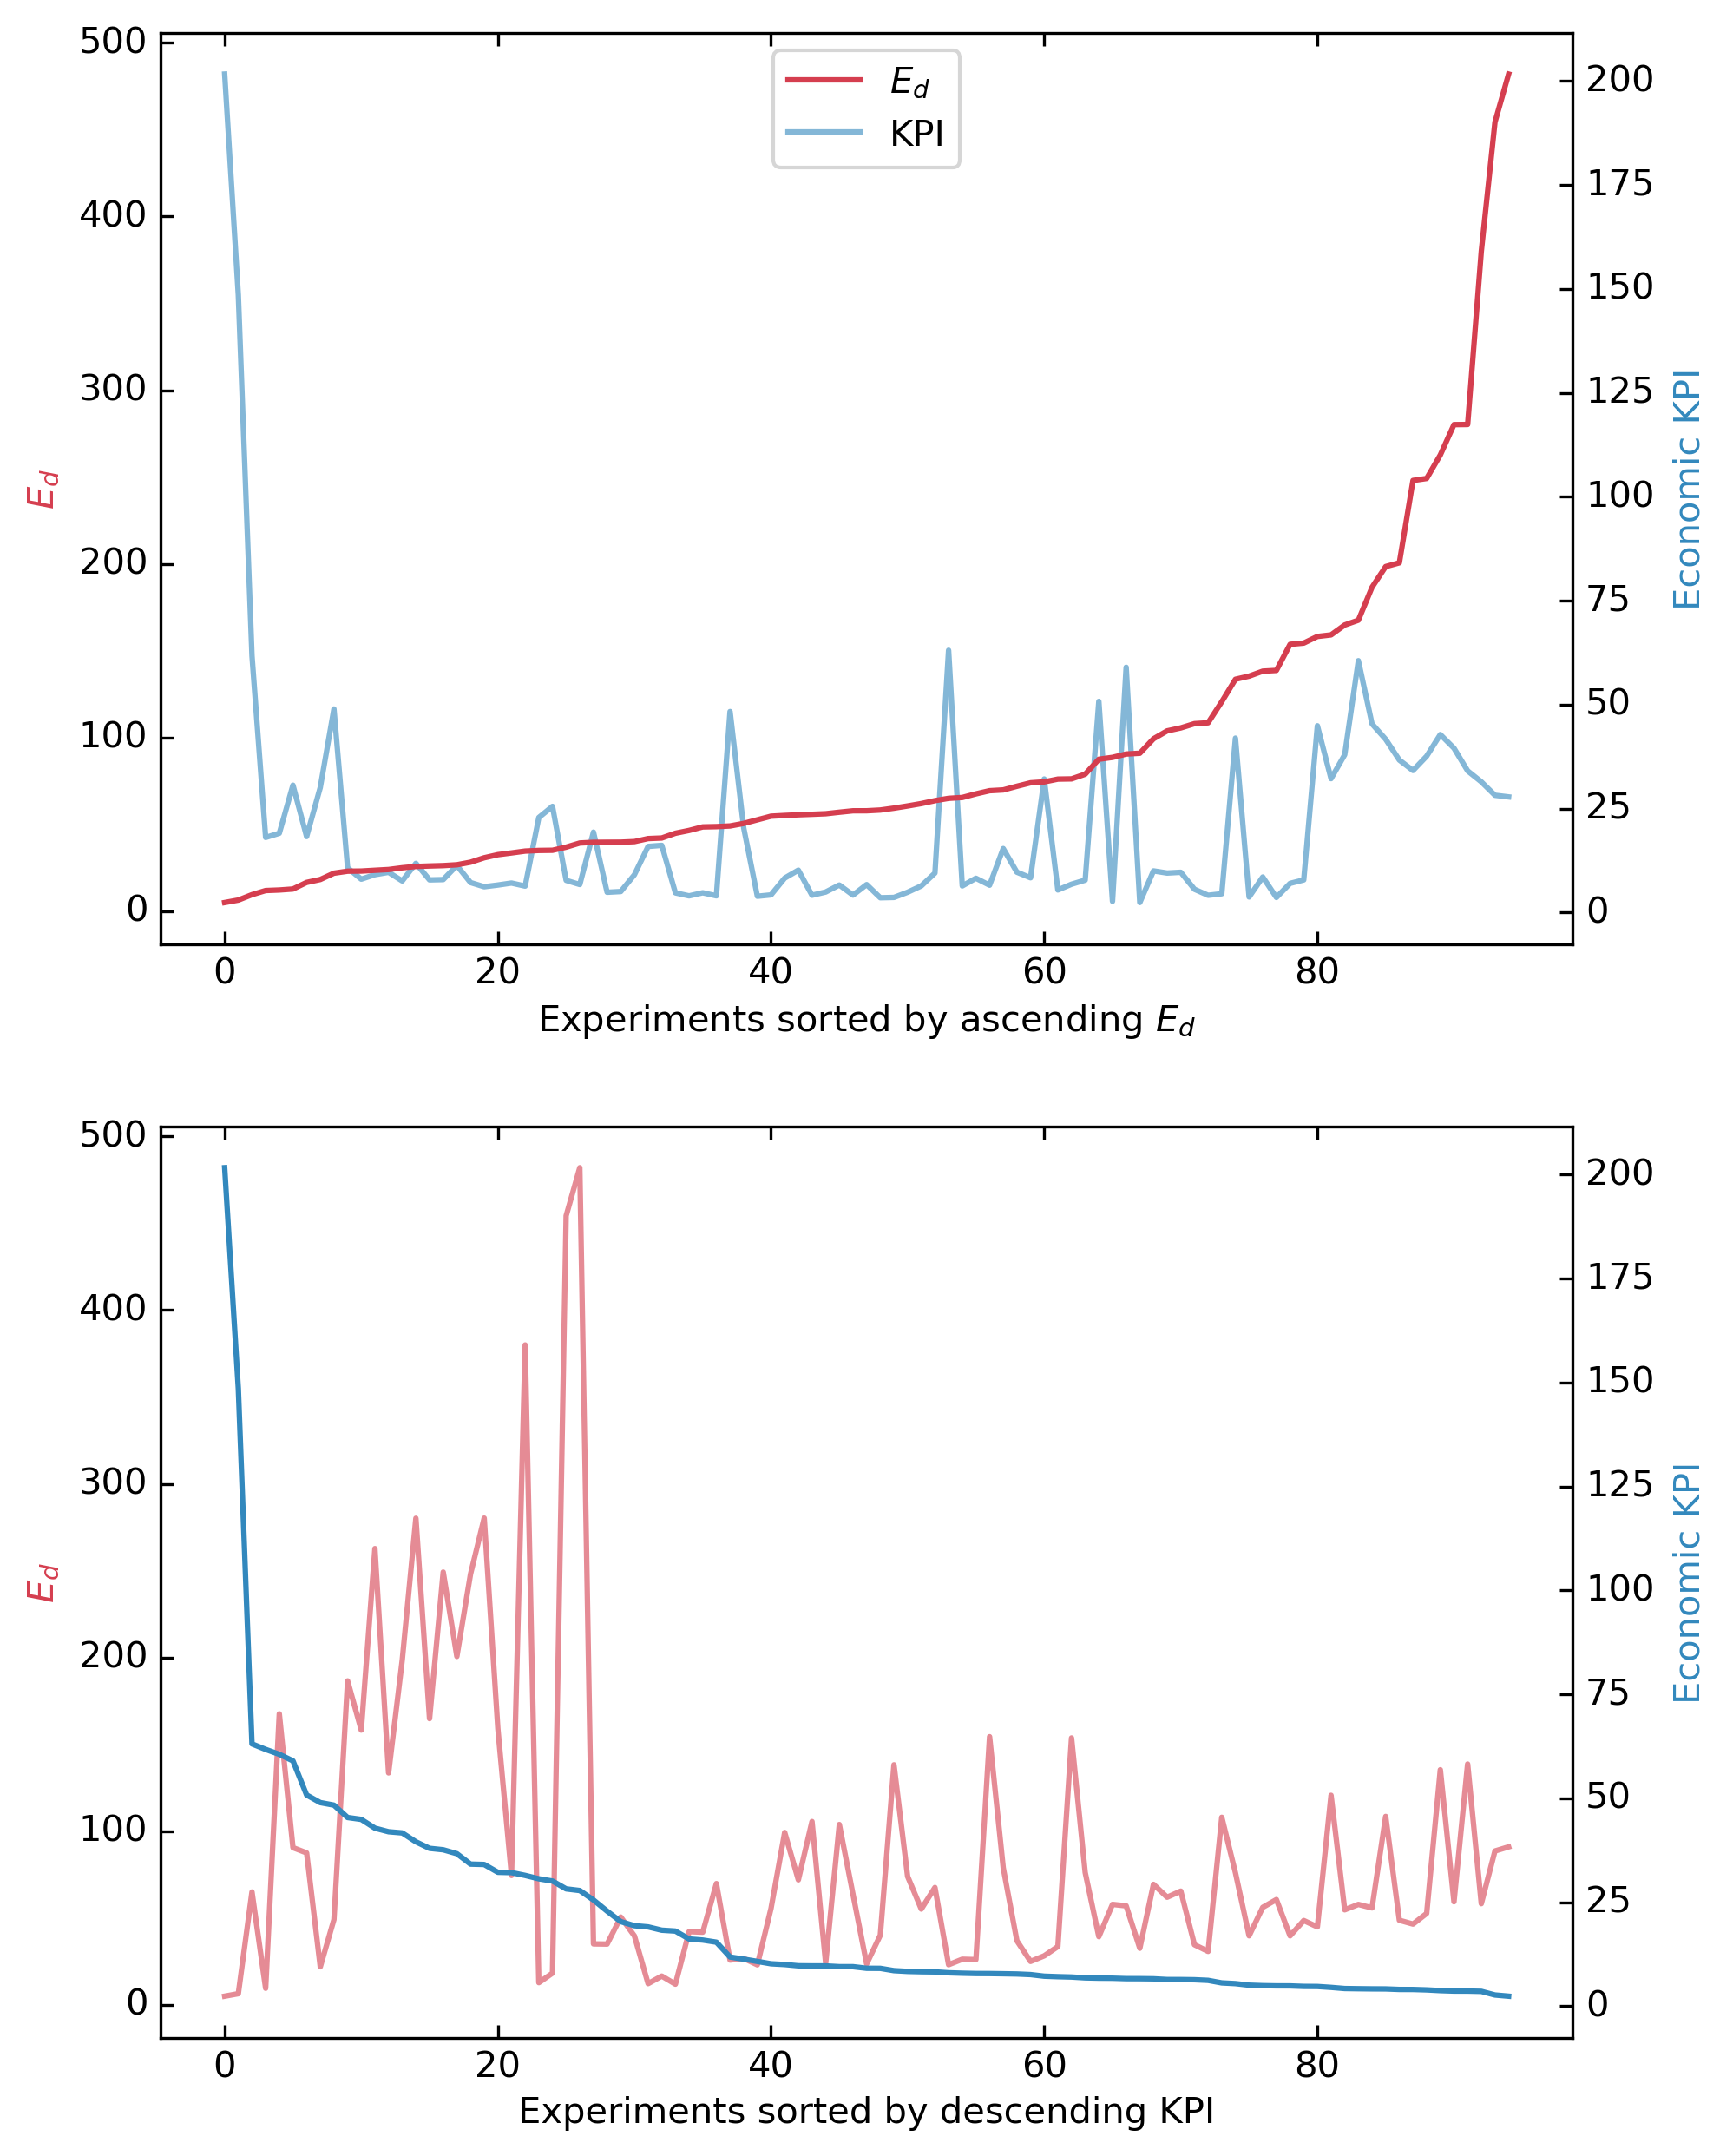

In [11]:
# Create figure
figure = plt.figure(figsize=(7, 10), dpi=300)

# Sort by E_d
df_sorted_Ed = df_clean.sort_values("E_d").reset_index(drop=True)

# Host axis (left y-axis for E_d)
host = host_subplot(211, axes_class=AA.Axes)

# Create two parasite axis for the right side
par1 = host.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host.plot(
    df_sorted_Ed.index, df_sorted_Ed["E_d"], color="#d53e4f", label=r"$E_d$", zorder=3
)
(p2,) = par1.plot(
    df_sorted_Ed.index, df_sorted_Ed["KPI"], color="#3288bd", label="KPI", alpha=0.6
)

# Axis labels
host.set_xlabel(r"Experiments sorted by ascending $E_d$")
host.set_ylabel(r"$E_d$")
par1.set_ylabel("Economic KPI")

# Colors match the plots
host.axis["left"].label.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())

# Legend
lines = [p1, p2]
host.legend(lines, [line.get_label() for line in lines], loc="upper center")


# Sord by KPI
df_sorted_KPI = df_clean.sort_values("KPI", ascending=False).reset_index(drop=True)

# Host axis (left y-axis for E_d)
host2 = host_subplot(212, axes_class=AA.Axes)

# Create two parasite axes for the right side
par1 = host2.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host2.plot(
    df_sorted_KPI.index,
    df_sorted_KPI["E_d"],
    color="#d53e4f",
    label=r"$E_d$",
    alpha=0.6,
)
(p2,) = par1.plot(
    df_sorted_KPI.index, df_sorted_KPI["KPI"], color="#3288bd", label="KPI", zorder=3
)

# Axis labels
host2.set_xlabel(r"Experiments sorted by descending KPI")
host2.set_ylabel(r"$E_d$")
par1.set_ylabel("Economic KPI")

# Colors match the plots
host2.axis["left"].label.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())


plt.savefig("plots/sorted.pdf", dpi=300, bbox_inches="tight")
plt.savefig("plots/sorted.svg", dpi=300, bbox_inches="tight")
plt.show()

### Chronological

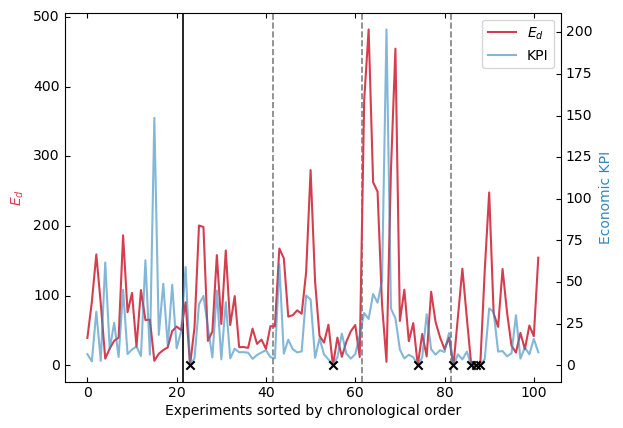

In [13]:
df_unsorted = experiment_data
df_unsorted.loc[df_unsorted["Notes"] == "Penalizzato", "E_d"] = 0
df_unsorted.loc[df_unsorted["Notes"] == "Penalizzato", "KPI"] = 0

penalized_pts = df_unsorted.loc[df_unsorted["Notes"] == "Penalizzato"]

# Host axis (left y-axis for E_d)
host = host_subplot(111, axes_class=AA.Axes)

# Create parasite axis for the right side
par1 = host.twinx()

# Offset the third y-axis (so they don’t overlap)
par1.axis["right"].toggle(all=True)  # turn on ticks and label for KPI axis

# Plot data
(p1,) = host.plot(
    df_unsorted.index, df_unsorted["E_d"], color="#d53e4f", label=r"$E_d$", zorder=2
)

host.scatter(penalized_pts.index, penalized_pts["E_d"], color="k", marker="x", zorder=3)

(p2,) = par1.plot(
    df_unsorted.index, df_unsorted["KPI"], color="#3288bd", label="KPI", alpha=0.6
)

# vertical lines on the shared x-axis (host)
host.axvline(
    x=21.5, color="black", linestyle="-", linewidth=1.2, zorder=0
)  # solid black
for xpos in [41.5, 61.5, 81.5]:
    host.axvline(
        x=xpos, color="gray", linestyle="--", linewidth=1.2, zorder=0
    )  # dashed gray

# Axis labels
host.set_xlabel("Experiments sorted by chronological order")
host.set_ylabel(r"$E_d$")
par1.set_ylabel("Economic KPI")

# Colors match the plots
host.axis["left"].label.set_color(p1.get_color())
par1.axis["right"].label.set_color(p2.get_color())

# Legend
lines = [p1, p2]
host.legend(lines, [line.get_label() for line in lines], loc="best")

plt.savefig("plots/chronological.pdf", dpi=300, bbox_inches="tight")
plt.savefig("plots/chronological.svg", dpi=300, bbox_inches="tight")

plt.show()

# Pareto front

In [11]:
def is_pareto_efficient(costs, return_mask=True):
    """
    Find the Pareto-efficient points.
    Args:
        costs: (n_points, n_costs) array. Lower values are better.
        return_mask: If True, returns a boolean mask. Otherwise, indices.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Any point that is strictly worse in all objectives is dominated
            is_efficient[is_efficient] = np.any(
                costs[is_efficient] < c, axis=1
            ) | np.all(costs[is_efficient] == c, axis=1)
    return is_efficient if return_mask else np.where(is_efficient)[0]

In [12]:
f1 = df_clean["E_d"]  # Objective 1 (to MAXIMIZE)
f2 = df_clean["KPI"]  # Objective 2 (to MINIMIZE)

# Define optimization directions (+1 for minimize, -1 for maximize)
# Here: maximize f1, minimize f2
directions = np.array([-1, 1])

# Convert all objectives to a "cost" form (lower is better)
costs = np.column_stack((f1, f2)) * directions

# === Compute Pareto front ===
mask = is_pareto_efficient(costs)
pareto_points = np.column_stack((f1, f2))[mask]
dominated_points = np.column_stack((f1, f2))[~mask]

# === Sort front for prettier plotting ===
pareto_points = pareto_points[np.argsort(pareto_points[:, 0])]

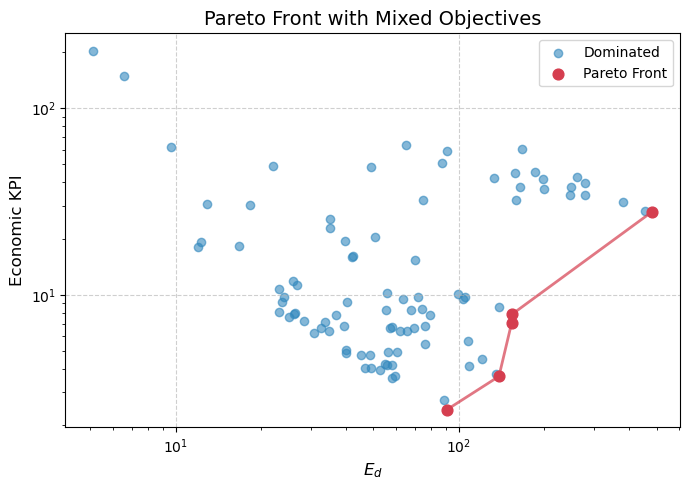

In [13]:
# === Plot ===
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(
    dominated_points[:, 0],
    dominated_points[:, 1],
    color="#3288bd",
    alpha=0.6,
    label="Dominated",
)
ax.scatter(
    pareto_points[:, 0],
    pareto_points[:, 1],
    color="#d53e4f",
    s=60,
    label="Pareto Front",
)
ax.loglog(pareto_points[:, 0], pareto_points[:, 1], color="#d53e4f", lw=2, alpha=0.7)

plt.xlabel(r"$E_d$", fontsize=12)
plt.ylabel("Economic KPI", fontsize=12)

plt.title("Pareto Front with Mixed Objectives", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("plots/pareto.pdf", dpi=300, bbox_inches="tight")
plt.savefig("plots/pareto.svg", dpi=300, bbox_inches="tight")
plt.show()